# Stacking Ensemble — crash severity classification

Stacking ensemble adapted from Rafe et al. (2024) for the RTA dataset.

## Architecture

The original paper used a stacking ensemble of XGBoost + ExtraTrees + Logistic Regression
(base) with Logistic Regression (meta). We retain the architecture but fix several
issues found in the original notebook:

1. **Data leakage**: original applied SMOTE *before* the train/test split, which
   leaks synthetic minority samples into the test set. We split first, then SMOTE
   only on the training fold.
2. **Untuned base learners**: the original tuned only XGBoost via GridSearchCV.
   ExtraTrees and the meta LR used defaults. We tune all three via Optuna with CV.
3. **No scaling for LR base**: LR needs scaled features. We wrap it in an inner
   pipeline so its inputs are scaled, while the trees see raw ordinal codes.
4. **No early stopping**: XGBoost base learner now uses early stopping inside
   the search space via `n_estimators`.

## Pipeline

1. Load `data/data_cleaned.csv`, define feature set, train / val / test split.
2. OrdinalEncoder on categoricals (trees handle ordinal codes natively).
3. Optuna jointly searches XGBoost + ExtraTrees + LR hyperparameters with
   stratified k-fold CV. SMOTE on the training fold only.
4. Train final stacking ensemble on full training set (with SMOTE).
5. Test set evaluation: accuracy, precision, recall, F1, AUC, confusion matrix.
6. Per-class threshold tuning with line plots.
7. SHAP analysis (KernelExplainer) and a sensitivity / post-hoc study.
8. Save model and metrics.

GPU: XGBoost uses `device='cuda'` when available; ExtraTrees and LR are CPU-only.

Color convention: Fatal = red, Serious = yellow, Slight = green.


## 1. Setup

In [2]:
import json
import logging
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import optuna
import shap

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger("stacking")
# SHAP / matplotlib loggers are very chatty at INFO; pin to WARNING.
logging.getLogger("shap").setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

SEED = 42
np.random.seed(SEED)

# GPU detection — XGBoost can use CUDA; sklearn estimators stay on CPU.
try:
    import torch
    XGB_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    if XGB_DEVICE == "cuda":
        log.info(f"GPU: {torch.cuda.get_device_name(0)}")
except ImportError:
    XGB_DEVICE = "cpu"
log.info(f"XGBoost device: {XGB_DEVICE}")

# Paths and run config.
ROOT = Path.cwd()
DATA = ROOT / "data" / "data_cleaned.csv"
MODEL_DIR = ROOT / "models"
FIG_DIR = ROOT / "outputs" / "figures"
RESULTS = ROOT / "outputs" / "stacking_metrics.json"
for p in (MODEL_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

# Hyperparameter search budget.
N_TRIALS = 50
N_FOLDS = 5
SHAP_BG = 100
SHAP_EVAL = 200

SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
SEVERITY_COLORS = {"Slight Injury": "#2ca02c", "Serious Injury": "#f1c40f", "Fatal injury": "#d62728"}
SEVERITY_PALETTE = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]
SEV_SHORT = ["Slight", "Serious", "Fatal"]


18:02:13 [INFO] GPU: NVIDIA GeForce RTX 5060
18:02:13 [INFO] XGBoost device: cuda


## 2. Helpers

`encode()` is a tree-friendly version of the same encoder used in the TabNet
notebook: OrdinalEncoder shifts unknowns to a reserved 0 slot. Trees do not
need scaling (the LR base learner gets a StandardScaler inside its own pipeline).


In [3]:
def define_features(df: pd.DataFrame):
    """Same feature contract as the TabNet notebook so the two models can be
    compared directly. The four `_ord` columns replace their string counterparts."""
    drop_originals_with_ord = [
        "Age_band_of_driver", "Driving_experience",
        "Service_year_of_vehicle", "Educational_level",
    ]
    target_cols = ["Accident_severity", "Severity_code"]
    cat_cols = [c for c in df.select_dtypes(include="object").columns
                if c not in target_cols + drop_originals_with_ord]
    num_cols = [c for c in df.select_dtypes(include=["int64", "float64"]).columns
                if c not in target_cols]
    return cat_cols, num_cols


def encode(df, cat_cols, num_cols, encoder=None, fit=True):
    """OrdinalEncoder for tree-friendly inputs. +1 shift mirrors the TabNet
    notebook (kept for parity even though trees don't strictly need it)."""
    cat = df[cat_cols].astype(str).values
    num = df[num_cols].astype(float).values

    if fit:
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        cat_enc = encoder.fit_transform(cat)
    else:
        cat_enc = encoder.transform(cat)

    cat_enc = cat_enc + 1
    X = np.concatenate([cat_enc, num], axis=1).astype(np.float32)
    return X, encoder


def metric_block(y_true, y_pred, y_proba, label=""):
    out = {
        "accuracy":         accuracy_score(y_true, y_pred),
        "precision_macro":  precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":     recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":         f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted":      f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr":      roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }
    print(f"=== {label} ===")
    for k, v in out.items():
        print(f"  {k:<18s} {v:.4f}")
    print("\n  classification report:")
    print(classification_report(y_true, y_pred, target_names=SEV_SHORT, zero_division=0))
    return out


def plot_confusion(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(SEV_SHORT); ax.set_yticklabels(SEV_SHORT)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


## 3. Load data and split

Identical split to the TabNet notebook (same seed, same proportions, same
stratification) so the two models are directly comparable.


In [4]:
df = pd.read_csv(DATA)
cat_cols, num_cols = define_features(df)
feature_names = cat_cols + num_cols

log.info(f"data shape: {df.shape}")
log.info(f"cat features ({len(cat_cols)}): {cat_cols}")
log.info(f"num features ({len(num_cols)}): {num_cols}")

y = df["Severity_code"].values
print(pd.Series(y).map(dict(enumerate(SEV_SHORT))).value_counts())


18:02:13 [INFO] data shape: (12316, 32)
18:02:13 [INFO] cat features (17): ['Day_of_week', 'Sex_of_driver', 'Vehicle_driver_relation', 'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Cause_of_accident', 'TimeOfDay']
18:02:13 [INFO] num features (9): ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour', 'RushHour', 'IsWeekend', 'Age_band_of_driver_ord', 'Driving_experience_ord', 'Service_year_of_vehicle_ord', 'Educational_level_ord']


Slight     10415
Serious     1743
Fatal        158
Name: count, dtype: int64


In [5]:
df_trainval, df_test = train_test_split(
    df, test_size=0.15, stratify=y, random_state=SEED)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.1765,
    stratify=df_trainval["Severity_code"].values, random_state=SEED)

log.info(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")

X_train, encoder = encode(df_train, cat_cols, num_cols, fit=True)
X_val, _ = encode(df_val, cat_cols, num_cols, encoder, fit=False)
X_test, _ = encode(df_test, cat_cols, num_cols, encoder, fit=False)
y_train = df_train["Severity_code"].values
y_val = df_val["Severity_code"].values
y_test = df_test["Severity_code"].values
log.info(f"feature dim: {X_train.shape[1]}")


18:02:13 [INFO] train=8620  val=1848  test=1848
18:02:13 [INFO] feature dim: 26


## 4. Optuna hyperparameter search

Tunes XGBoost (5 params), ExtraTrees (3 params) and the LR base C in a single
joint study. Per-trial cost: 5-fold CV × 3 base learners × stacking inner CV;
the inner CV is the StackingClassifier's own cross-validation when generating
out-of-fold predictions for the meta learner.

Objective: macro-F1 — same justification as TabNet (Fatal class is rare).


In [6]:
def build_stacking(xgb_params, et_params, lr_C, stack_cv=5):
    xgb = XGBClassifier(
        objective="multi:softprob", num_class=3,
        tree_method="hist", device=XGB_DEVICE,
        eval_metric="mlogloss", random_state=SEED, verbosity=0,
        **xgb_params,
    )
    et = ExtraTreesClassifier(random_state=SEED, n_jobs=-1, **et_params)

    # LR base learner: scale features inside its own pipeline so the LR sees
    # standardized inputs while the trees see raw ordinal codes.
    lr_base = Pipeline([
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(solver="saga", max_iter=3000,
                                  C=lr_C, random_state=SEED, n_jobs=-1)),
    ])

    estimators = [("lr", lr_base), ("xgb", xgb), ("et", et)]
    final = LogisticRegression(solver="saga", max_iter=3000,
                               random_state=SEED, n_jobs=-1)
    return StackingClassifier(
        estimators=estimators, final_estimator=final,
        cv=stack_cv, n_jobs=1, passthrough=False)


class OptunaProgress:
    def __init__(self, total): self.total = total; self.t0 = time.time()

    def __call__(self, study, trial):
        elapsed = time.time() - self.t0
        avg = elapsed / (trial.number + 1)
        eta = avg * (self.total - trial.number - 1)
        log.info(f"trial {trial.number + 1:>2d}/{self.total} | "
                 f"value={trial.value:.4f} | best={study.best_value:.4f} | "
                 f"elapsed={elapsed:>6.1f}s | ETA={eta:>6.1f}s")


In [7]:
def objective(trial):
    xgb_params = dict(
        n_estimators=trial.suggest_int("xgb_n_estimators", 100, 400),
        max_depth=trial.suggest_int("xgb_max_depth", 3, 8),
        learning_rate=trial.suggest_float("xgb_lr", 0.02, 0.25, log=True),
        subsample=trial.suggest_float("xgb_subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("xgb_colsample", 0.6, 1.0),
        reg_alpha=trial.suggest_float("xgb_reg_alpha", 1e-4, 1.0, log=True),
        reg_lambda=trial.suggest_float("xgb_reg_lambda", 1e-4, 1.0, log=True),
        min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 8),
    )
    et_params = dict(
        n_estimators=trial.suggest_int("et_n_estimators", 200, 600),
        max_depth=trial.suggest_int("et_max_depth", 6, 30),
        min_samples_split=trial.suggest_int("et_min_split", 2, 12),
        min_samples_leaf=trial.suggest_int("et_min_leaf", 1, 6),
    )
    lr_C = trial.suggest_float("lr_C", 0.01, 10.0, log=True)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_scores = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        sm = SMOTE(random_state=SEED, k_neighbors=5)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        # Inner stacking CV uses 3 folds during search (faster); final uses 5.
        model = build_stacking(xgb_params, et_params, lr_C, stack_cv=3)
        model.fit(X_tr_sm, y_tr_sm)
        preds = model.predict(X_va)
        fold_scores.append(f1_score(y_va, preds, average="macro"))
    return float(np.mean(fold_scores))


In [8]:
log.info(f"Starting Optuna search: {N_TRIALS} trials, {N_FOLDS}-fold CV")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
)
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[OptunaProgress(N_TRIALS)])
log.info(f"Optuna done in {time.time() - t0:.1f}s")
log.info(f"best macro-F1: {study.best_value:.4f}")
log.info(f"best params: {study.best_params}")

best_params = dict(study.best_params)


18:02:13 [INFO] Starting Optuna search: 50 trials, 5-fold CV
18:02:53 [INFO] trial  1/50 | value=0.4404 | best=0.4404 | elapsed=  39.7s | ETA=1947.4s
18:03:14 [INFO] trial  2/50 | value=0.4371 | best=0.4404 | elapsed=  61.1s | ETA=1467.2s
18:03:50 [INFO] trial  3/50 | value=0.3759 | best=0.4404 | elapsed=  97.2s | ETA=1522.7s
18:04:17 [INFO] trial  4/50 | value=0.4389 | best=0.4404 | elapsed= 123.8s | ETA=1423.5s
18:05:05 [INFO] trial  5/50 | value=0.4553 | best=0.4553 | elapsed= 172.3s | ETA=1550.6s
18:05:35 [INFO] trial  6/50 | value=0.4388 | best=0.4553 | elapsed= 202.3s | ETA=1483.2s
18:06:03 [INFO] trial  7/50 | value=0.4238 | best=0.4553 | elapsed= 229.5s | ETA=1409.7s
18:06:40 [INFO] trial  8/50 | value=0.4484 | best=0.4553 | elapsed= 266.5s | ETA=1399.3s
18:07:21 [INFO] trial  9/50 | value=0.4389 | best=0.4553 | elapsed= 307.8s | ETA=1402.1s
18:07:57 [INFO] trial 10/50 | value=0.3960 | best=0.4553 | elapsed= 343.5s | ETA=1374.0s
18:08:53 [INFO] trial 11/50 | value=0.4534 | best

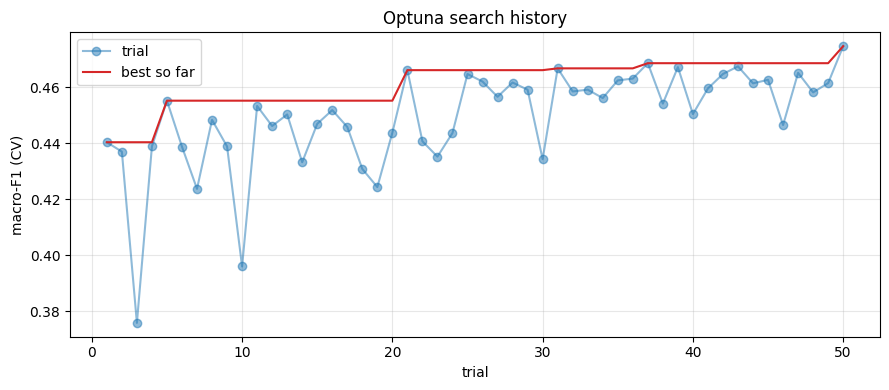

In [9]:
trial_vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(trial_vals) + 1), trial_vals, "o-", alpha=0.5, label="trial")
ax.plot(range(1, len(running_best) + 1), running_best, "-", color="#d62728", label="best so far")
ax.set_xlabel("trial"); ax.set_ylabel("macro-F1 (CV)")
ax.set_title("Optuna search history")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "stacking_optuna_history.png", dpi=150)
plt.show()


## 5. Train final stacking ensemble

In [10]:
log.info("SMOTE on full training set ...")
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
log.info(f"SMOTE: {len(y_train)} -> {len(y_train_sm)}")
log.info(f"class counts after SMOTE: {pd.Series(y_train_sm).value_counts().sort_index().tolist()}")

bp = best_params
final_model = build_stacking(
    xgb_params=dict(
        n_estimators=bp["xgb_n_estimators"],
        max_depth=bp["xgb_max_depth"],
        learning_rate=bp["xgb_lr"],
        subsample=bp["xgb_subsample"],
        colsample_bytree=bp["xgb_colsample"],
        reg_alpha=bp["xgb_reg_alpha"],
        reg_lambda=bp["xgb_reg_lambda"],
        min_child_weight=bp["xgb_min_child_weight"],
    ),
    et_params=dict(
        n_estimators=bp["et_n_estimators"],
        max_depth=bp["et_max_depth"],
        min_samples_split=bp["et_min_split"],
        min_samples_leaf=bp["et_min_leaf"],
    ),
    lr_C=bp["lr_C"],
    stack_cv=5,
)
t0 = time.time()
final_model.fit(X_train_sm, y_train_sm)
log.info(f"final fit in {time.time() - t0:.1f}s")


18:37:59 [INFO] SMOTE on full training set ...
18:37:59 [INFO] SMOTE: 8620 -> 21867
18:37:59 [INFO] class counts after SMOTE: [7289, 7289, 7289]
18:38:18 [INFO] final fit in 18.6s


In [11]:
# Quick validation-set sanity check before going to the held-out test set.
val_pred = final_model.predict(X_val)
val_proba = final_model.predict_proba(X_val)
_ = metric_block(y_val, val_pred, val_proba, label="Validation set")


=== Validation set ===
  accuracy           0.8420
  precision_macro    0.4966
  recall_macro       0.3923
  f1_macro           0.4089
  f1_weighted        0.8076
  roc_auc_ovr        0.7062

  classification report:
              precision    recall  f1-score   support

      Slight       0.86      0.97      0.91      1563
     Serious       0.48      0.17      0.25       261
       Fatal       0.14      0.04      0.06        24

    accuracy                           0.84      1848
   macro avg       0.50      0.39      0.41      1848
weighted avg       0.80      0.84      0.81      1848



## 6. Test set evaluation

=== Test set (argmax) ===
  accuracy           0.8512
  precision_macro    0.6430
  recall_macro       0.4317
  f1_macro           0.4681
  f1_weighted        0.8129
  roc_auc_ovr        0.6974

  classification report:
              precision    recall  f1-score   support

      Slight       0.86      0.98      0.92      1563
     Serious       0.57      0.15      0.24       261
       Fatal       0.50      0.17      0.25        24

    accuracy                           0.85      1848
   macro avg       0.64      0.43      0.47      1848
weighted avg       0.82      0.85      0.81      1848



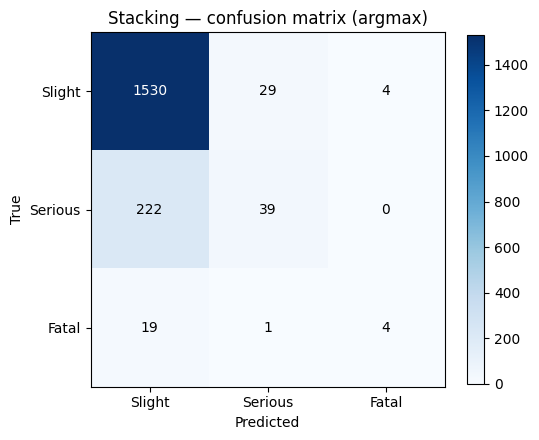

In [12]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

test_metrics = metric_block(y_test, y_pred, y_proba, label="Test set (argmax)")
cm = confusion_matrix(y_test, y_pred)
plot_confusion(cm, "Stacking — confusion matrix (argmax)",
               save_path=FIG_DIR / "stacking_confusion_argmax.png")


## 7. Per-class threshold tuning

Same approach as the TabNet notebook: sweep one-vs-rest thresholds and pick
the per-class F1 maximum.


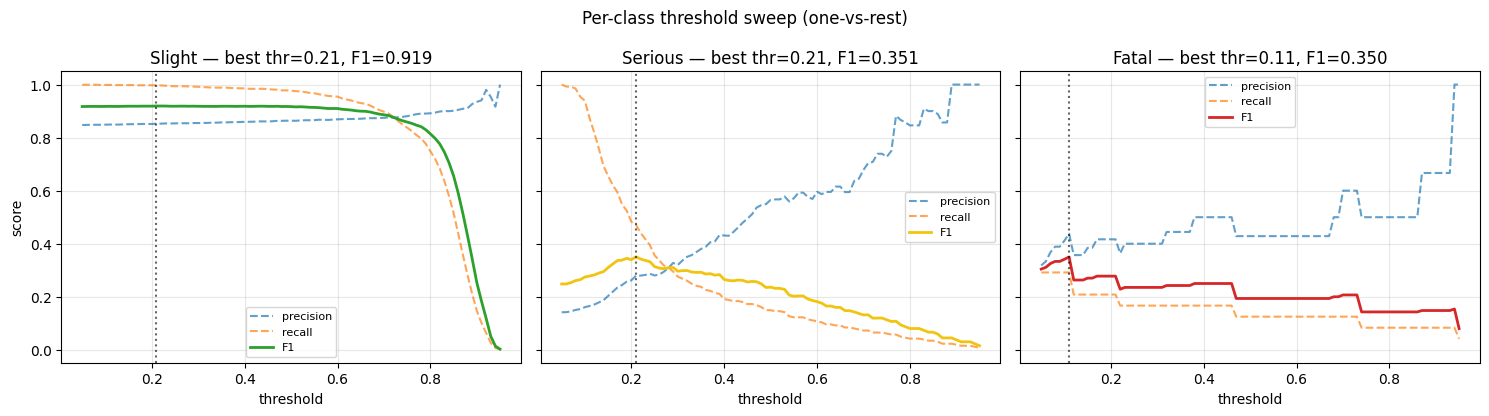

Best per-class thresholds: {'Slight': 0.20999999999999996, 'Serious': 0.20999999999999996, 'Fatal': 0.10999999999999999}


In [13]:
thresholds = np.linspace(0.05, 0.95, 91)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
best_thr = {}

for k, (name, color) in enumerate(zip(SEV_SHORT, SEVERITY_PALETTE)):
    f1s, pres, recs = [], [], []
    y_bin = (y_test == k).astype(int)
    for thr in thresholds:
        p_bin = (y_proba[:, k] >= thr).astype(int)
        f1s.append(f1_score(y_bin, p_bin, zero_division=0))
        pres.append(precision_score(y_bin, p_bin, zero_division=0))
        recs.append(recall_score(y_bin, p_bin, zero_division=0))

    f1s = np.array(f1s); pres = np.array(pres); recs = np.array(recs)
    best_idx = int(np.argmax(f1s))
    best_thr[name] = float(thresholds[best_idx])

    ax = axes[k]
    ax.plot(thresholds, pres, label="precision", color="#1f77b4", linestyle="--", alpha=0.7)
    ax.plot(thresholds, recs, label="recall",    color="#ff7f0e", linestyle="--", alpha=0.7)
    ax.plot(thresholds, f1s,  label="F1",        color=color, linewidth=2)
    ax.axvline(thresholds[best_idx], color="black", linestyle=":", alpha=0.6)
    ax.set_title(f"{name} — best thr={thresholds[best_idx]:.2f}, F1={f1s[best_idx]:.3f}")
    ax.set_xlabel("threshold")
    if k == 0: ax.set_ylabel("score")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Per-class threshold sweep (one-vs-rest)")
plt.tight_layout()
plt.savefig(FIG_DIR / "stacking_threshold_sweep.png", dpi=150)
plt.show()
print("Best per-class thresholds:", best_thr)


=== Test set (threshold-tuned) ===
  accuracy           0.8512
  precision_macro    0.6430
  recall_macro       0.4317
  f1_macro           0.4681
  f1_weighted        0.8129
  roc_auc_ovr        0.6974

  classification report:
              precision    recall  f1-score   support

      Slight       0.86      0.98      0.92      1563
     Serious       0.57      0.15      0.24       261
       Fatal       0.50      0.17      0.25        24

    accuracy                           0.85      1848
   macro avg       0.64      0.43      0.47      1848
weighted avg       0.82      0.85      0.81      1848



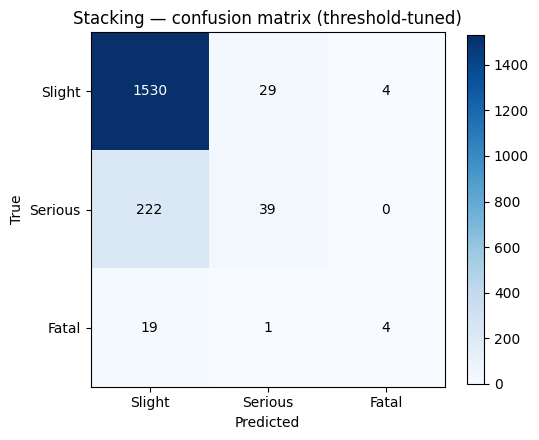

In [14]:
def predict_with_thresholds(proba, thr_map):
    thr_arr = np.array([thr_map[n] for n in SEV_SHORT])
    above = proba >= thr_arr
    out = np.full(len(proba), -1, dtype=int)
    for i in range(len(proba)):
        if above[i].any():
            cand = np.where(above[i])[0]
            out[i] = cand[np.argmax(proba[i, cand])]
        else:
            out[i] = int(np.argmax(proba[i]))
    return out


y_pred_tuned = predict_with_thresholds(y_proba, best_thr)
tuned_metrics = metric_block(y_test, y_pred_tuned, y_proba,
                             label="Test set (threshold-tuned)")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plot_confusion(cm_tuned, "Stacking — confusion matrix (threshold-tuned)",
               save_path=FIG_DIR / "stacking_confusion_tuned.png")


## 8. Save model and metrics

In [15]:
save_path = MODEL_DIR / "stacking_best.joblib"
joblib.dump({
    "model": final_model,
    "encoder": encoder,
    "cat_cols": cat_cols, "num_cols": num_cols,
    "feature_names": feature_names,
    "best_params": best_params,
    "best_thresholds": best_thr,
}, save_path)

results = {
    "best_params": best_params,
    "best_thresholds": best_thr,
    "test_argmax": test_metrics,
    "test_threshold_tuned": tuned_metrics,
    "confusion_argmax": cm.tolist(),
    "confusion_tuned": cm_tuned.tolist(),
    "n_train": int(len(y_train)), "n_val": int(len(y_val)), "n_test": int(len(y_test)),
}
RESULTS.write_text(json.dumps(results, indent=2))
log.info(f"Saved model to {save_path}")
log.info(f"Wrote {RESULTS}")


18:38:20 [INFO] Saved model to /home/thsondev/Projects/crash-severity-tabnet-stacking/models/stacking_best.joblib
18:38:20 [INFO] Wrote /home/thsondev/Projects/crash-severity-tabnet-stacking/outputs/stacking_metrics.json


## 9. SHAP interpretation

KernelExplainer on the stacking ensemble's `predict_proba`. The model is
slow per call so we keep background and evaluation samples small.


In [16]:
rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_train_sm), size=min(SHAP_BG, len(X_train_sm)), replace=False)
background = X_train_sm[bg_idx]

eval_idx = rng.choice(len(X_test), size=min(SHAP_EVAL, len(X_test)), replace=False)
X_shap = X_test[eval_idx]

log.info(f"SHAP: background={len(background)}, eval={len(X_shap)}")
explainer = shap.KernelExplainer(final_model.predict_proba, background)
t0 = time.time()
shap_values = explainer.shap_values(X_shap, nsamples=100)
log.info(f"SHAP done in {time.time() - t0:.1f}s; shape={np.array(shap_values).shape}")


18:38:20 [INFO] SHAP: background=100, eval=200
100%|██████████| 200/200 [00:41<00:00,  4.86it/s]
18:39:01 [INFO] SHAP done in 41.1s; shape=(200, 26, 3)


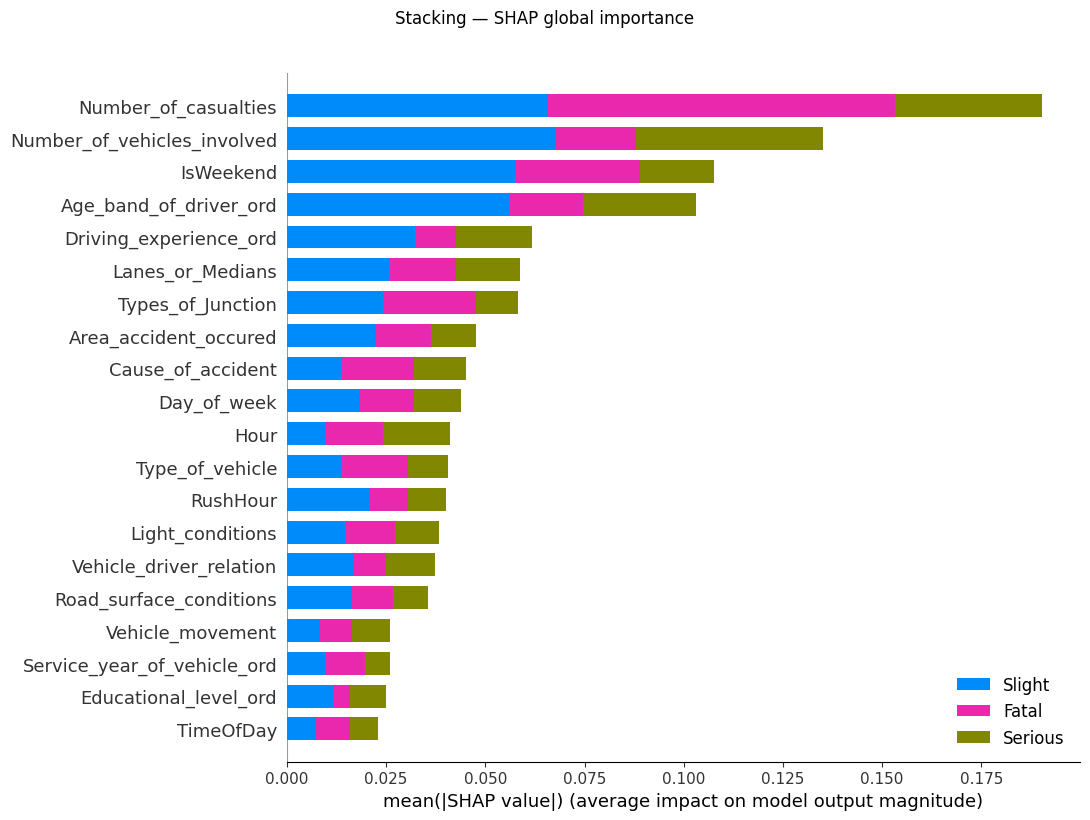

In [17]:
shap_per_class = [shap_values[:, :, k] for k in range(3)]

shap.summary_plot(shap_per_class, X_shap, feature_names=feature_names,
                  plot_type="bar", class_names=SEV_SHORT, show=False, plot_size=(11, 8))
fig = plt.gcf(); fig.suptitle("Stacking — SHAP global importance", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "stacking_shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()


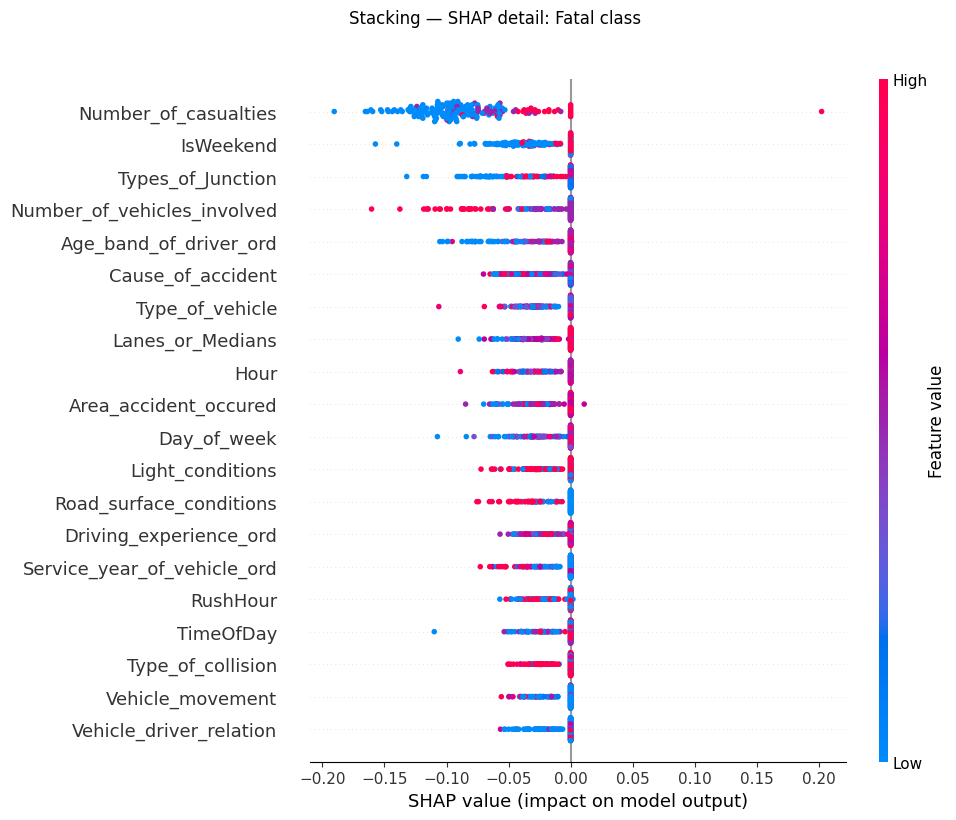

In [18]:
fatal_idx = SEV_SHORT.index("Fatal")
shap.summary_plot(shap_per_class[fatal_idx], X_shap, feature_names=feature_names,
                  plot_type="dot", show=False, plot_size=(10, 8))
fig = plt.gcf(); fig.suptitle("Stacking — SHAP detail: Fatal class", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "stacking_shap_dot_fatal.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Post-hoc / sensitivity analysis

Same intervention as the TabNet notebook (set `Light_conditions` to 'Daylight'
across the test set) so the two models can be compared on the same scenario.


Mean predicted probability shift after setting Light_conditions='Daylight':
  Slight   original=0.8041  intervened=0.8024  delta=-0.0017
  Serious  original=0.1848  intervened=0.1869  delta=+0.0021
  Fatal    original=0.0111  intervened=0.0107  delta=-0.0004


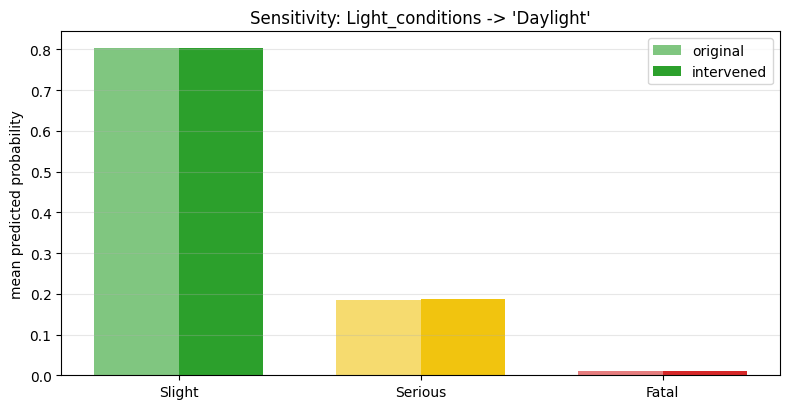

In [19]:
target_feature = "Light_conditions"
intervene_value = "Daylight"

if intervene_value not in df["Light_conditions"].unique():
    intervene_value = df["Light_conditions"].mode().iloc[0]
    log.info(f"'Daylight' not in data; intervening with '{intervene_value}' instead")

df_test_int = df_test.copy()
df_test_int[target_feature] = intervene_value
X_test_int, _ = encode(df_test_int, cat_cols, num_cols, encoder, fit=False)
proba_int = final_model.predict_proba(X_test_int)

orig_mean = y_proba.mean(axis=0)
intv_mean = proba_int.mean(axis=0)
delta = intv_mean - orig_mean

print(f"Mean predicted probability shift after setting {target_feature}='{intervene_value}':")
for name, o, i, d in zip(SEV_SHORT, orig_mean, intv_mean, delta):
    print(f"  {name:<8s} original={o:.4f}  intervened={i:.4f}  delta={d:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, orig_mean, width=w, color=SEVERITY_PALETTE, label="original", alpha=0.6)
ax.bar(x + w/2, intv_mean, width=w, color=SEVERITY_PALETTE, label="intervened", alpha=1.0)
ax.set_xticks(x); ax.set_xticklabels(SEV_SHORT)
ax.set_ylabel("mean predicted probability")
ax.set_title(f"Sensitivity: {target_feature} -> '{intervene_value}'")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "stacking_sensitivity_light.png", dpi=150)
plt.show()


## 11. Summary

- Best Optuna macro-F1 (CV): see log above.
- Argmax test metrics + threshold-tuned test metrics reported.
- Saved artefacts: `models/stacking_best.joblib`,
  `outputs/stacking_metrics.json`, and figures under `outputs/figures/`.

Run alongside `tabnet.ipynb` for direct comparison — both use the same
train/val/test split (same seed, same proportions) and the same feature contract.
